In [20]:
import pandas as pd
import yfinance as yf
from pytickersymbols import PyTickerSymbols
import time


# Dictionary mapping symbols to company names
# SYMBOL_NAMES = {
#     "AAPL": "Apple Inc.",
#     "MSFT": "Microsoft Corporation",
#     "NVDA": "NVIDIA Corporation",
#     "TSLA": "Tesla Inc.",
#     "AMZ": "Amazon Inc.",
#     "GOOGL": "Alphabet Inc.",
#     "META": "Meta Platforms",
#     "BRK.B": "Berkshire Hathaway",
#     "JNJ": "Johnson & Johnson",
#     "V": "Visa Inc.",
# }


def get_company_name(symbol: str) -> str:
    """Get company name for symbol, fetch if not in cache."""
    if symbol in SYMBOL_NAMES:
        return SYMBOL_NAMES[symbol]
    try:
        info = yf.Ticker(symbol).info
        return info.get("longName", symbol)
    except:
        return symbol


def get_top_5_symbols(limit: int = 50, source: str = "SP500", delay: float = 0.5) -> list[str]:
    """Get top 5 tickers by daily percentage move with rate limiting."""
    stock_data = PyTickerSymbols()
    
    # Use SP500 by default (more reliable than full US list)
    if source == "SP500":
        symbol_list = list(stock_data.get_sp_500_nyc_yahoo_tickers())[:limit]
    else:
        symbol_list = [s["symbol"] for s in list(stock_data.get_stocks_by_country("US"))[:limit]]

    print(f"Fetching data for {len(symbol_list)} symbols (with {delay}s delay)...")
    
    performance = []
    failed_count = 0
    success_count = 0
    
    for i, sym in enumerate(symbol_list):
        try:
            print(f"[{i+1}/{len(symbol_list)}] Fetching {sym}...", end="", flush=True)
            hist = yf.Ticker(sym).history(period="2d", interval="1d")
            
            if hist.empty or "Close" not in hist.columns or len(hist) < 2:
                print(" (no data)")
                continue

            prev_close = hist["Close"].iloc[-2]
            last_close = hist["Close"].iloc[-1]
            
            if pd.isna(prev_close) or pd.isna(last_close) or prev_close == 0:
                print(" (NaN/zero)")
                continue

            pct = (last_close - prev_close) / prev_close * 100
            performance.append((sym, pct))
            success_count += 1
            print(f" ✓ {pct:+.2f}%")
            
        except Exception as e:
            failed_count += 1
            error_msg = str(e)[:40]
            print(f" ✗ {error_msg}")
        
        # Rate limit: add delay between requests
        time.sleep(delay)

    print(f"\n✓ Successfully fetched {success_count} symbols. ✗ {failed_count} failed.")
    
    if not performance:
        print("WARNING: No valid symbols found. Using fallback symbols.")
        # Fallback: hardcoded symbols if API fails
        fallback_symbols = ["AAPL", "MSFT", "NVDA", "TSLA", "AMZ"]
        return fallback_symbols
    
    performance.sort(key=lambda x: x[1], reverse=True)
    top5 = [sym for sym, _ in performance[:5]]
    print(f"\nTop 5:")
    for sym, pct in performance[:5]:
        company_name = get_company_name(sym)
        print(f"  {sym} - {company_name}: {pct:+.2f}%")
    return top5


# Try SP500 first (more reliable), reduce limit to 50 to speed up fetching
# top5_symbols = get_top_5_symbols(limit=20, source="SP500", delay=0.7)
top5_symbols = get_top_5_symbols(limit=50, source="SP500", delay=0.7)
print(f"\nFinal Top 5: {top5_symbols}")

# Fetch OHLC data
ohlc_data = {}
for sym in top5_symbols:
    try:
        ohlc_data[sym] = yf.Ticker(sym).history(period="7d", interval="1d")[["Open", "High", "Low", "Close"]]
        print(f"✓ Fetched OHLC for {sym}")
    except Exception as e:
        print(f"✗ Failed OHLC for {sym}: {e}")

# Display with company names and formatted prices
for sym, df in ohlc_data.items():
    company_name = get_company_name(sym)
    print(f"\n{sym} - {company_name} (last 7 days):")
    # Format prices with $
    df_display = df.copy()
    for col in ["Open", "High", "Low", "Close"]:
        df_display[col] = "$" + df_display[col].apply(lambda x: f"{x:.2f}")
    print(df_display)

Fetching data for 50 symbols (with 0.7s delay)...
[1/50] Fetching MMM... ✓ +1.90%
[2/50] Fetching ABT... ✓ +0.78%
[3/50] Fetching ACN... ✓ +0.37%
[4/50] Fetching ADBE... ✓ +0.81%
[5/50] Fetching ALB... ✓ +1.30%
[6/50] Fetching ALGN... ✓ +3.11%
[7/50] Fetching ALLE... ✓ +1.68%
[8/50] Fetching GOOGL... ✓ +5.14%
[9/50] Fetching GOOG... ✓ +5.02%
[10/50] Fetching GOOGL... ✓ +5.14%
[11/50] Fetching GOOG... ✓ +5.02%
[12/50] Fetching AMZN... ✓ +3.64%
[13/50] Fetching AMCR... ✓ +4.30%
[14/50] Fetching AMCCF...

$AMCCF: possibly delisted; no price data found  (period=2d)


 (no data)
[15/50] Fetching AMGN... ✓ +0.82%
[16/50] Fetching AON... ✓ -0.39%
[17/50] Fetching APA... ✓ -2.97%
[18/50] Fetching AAPL... ✓ +2.90%
[19/50] Fetching APTV... ✓ +4.20%
[20/50] Fetching AJG... ✓ +0.29%
[21/50] Fetching T... ✓ +0.73%
[22/50] Fetching BKR... ✓ +0.61%
[23/50] Fetching BLL...

$BLL: possibly delisted; no price data found  (period=2d) (Yahoo error = "No data found, symbol may be delisted")


 (no data)
[24/50] Fetching BALY... ✓ -1.03%
[25/50] Fetching BALL... ✓ +1.86%
[26/50] Fetching BAC... ✓ +3.22%
[27/50] Fetching BOAPL...

$BOAPL: possibly delisted; no price data found  (period=2d) (Yahoo error = "No data found, symbol may be delisted")


 (no data)
[28/50] Fetching BAX... ✓ +6.33%
[29/50] Fetching BRK-B... ✓ +0.96%
[30/50] Fetching BLK... ✓ +2.96%
[31/50] Fetching BA... ✓ +5.19%
[32/50] Fetching BSX... ✓ -0.29%
[33/50] Fetching BRO... ✓ -0.08%
[34/50] Fetching CPT... ✓ -0.18%
[35/50] Fetching CCL... ✓ +8.01%
[36/50] Fetching CUK... ✓ +7.96%
[37/50] Fetching CUKPF... (no data)
[38/50] Fetching CAT... ✓ +6.15%
[39/50] Fetching CDW... ✓ +2.12%
[40/50] Fetching CNC... ✓ +2.96%
[41/50] Fetching SCHW... ✓ +0.99%
[42/50] Fetching CVX... ✓ -1.81%
[43/50] Fetching CB... ✓ +0.18%
[44/50] Fetching C... ✓ +5.72%
[45/50] Fetching KO... ✓ -0.29%
[46/50] Fetching CTSH... ✓ +0.47%
[47/50] Fetching COP... ✓ -0.67%
[48/50] Fetching GLW... ✓ +5.77%
[49/50] Fetching CRH... ✓ +3.15%
[50/50] Fetching CRHCF...

$CRHCF: possibly delisted; no price data found  (period=2d) (Yahoo error = "No data found, symbol may be delisted")


 (no data)

✓ Successfully fetched 45 symbols. ✗ 0 failed.

Top 5:
  CCL - Carnival Corporation & plc: +8.01%
  CUK - Carnival Corporation & plc: +7.96%
  BAX - Baxter International Inc.: +6.33%
  CAT - Caterpillar Inc.: +6.15%
  GLW - Corning Incorporated: +5.77%

Final Top 5: ['CCL', 'CUK', 'BAX', 'CAT', 'GLW']
✓ Fetched OHLC for CCL
✓ Fetched OHLC for CUK
✓ Fetched OHLC for BAX
✓ Fetched OHLC for CAT
✓ Fetched OHLC for GLW

CCL - Carnival Corporation & plc (last 7 days):
                             Open    High     Low   Close
Date                                                     
2026-03-23 00:00:00-04:00  $25.65  $26.22  $25.37  $25.45
2026-03-24 00:00:00-04:00  $24.76  $25.69  $24.71  $25.47
2026-03-25 00:00:00-04:00  $26.22  $26.39  $25.52  $25.73
2026-03-26 00:00:00-04:00  $25.39  $25.88  $25.16  $25.28
2026-03-27 00:00:00-04:00  $24.57  $25.46  $23.66  $24.19
2026-03-30 00:00:00-04:00  $24.39  $24.84  $23.79  $23.96
2026-03-31 00:00:00-04:00  $24.74  $25.93  $24.50  $25.88

Note: you may need to restart the kernel to use updated packages.


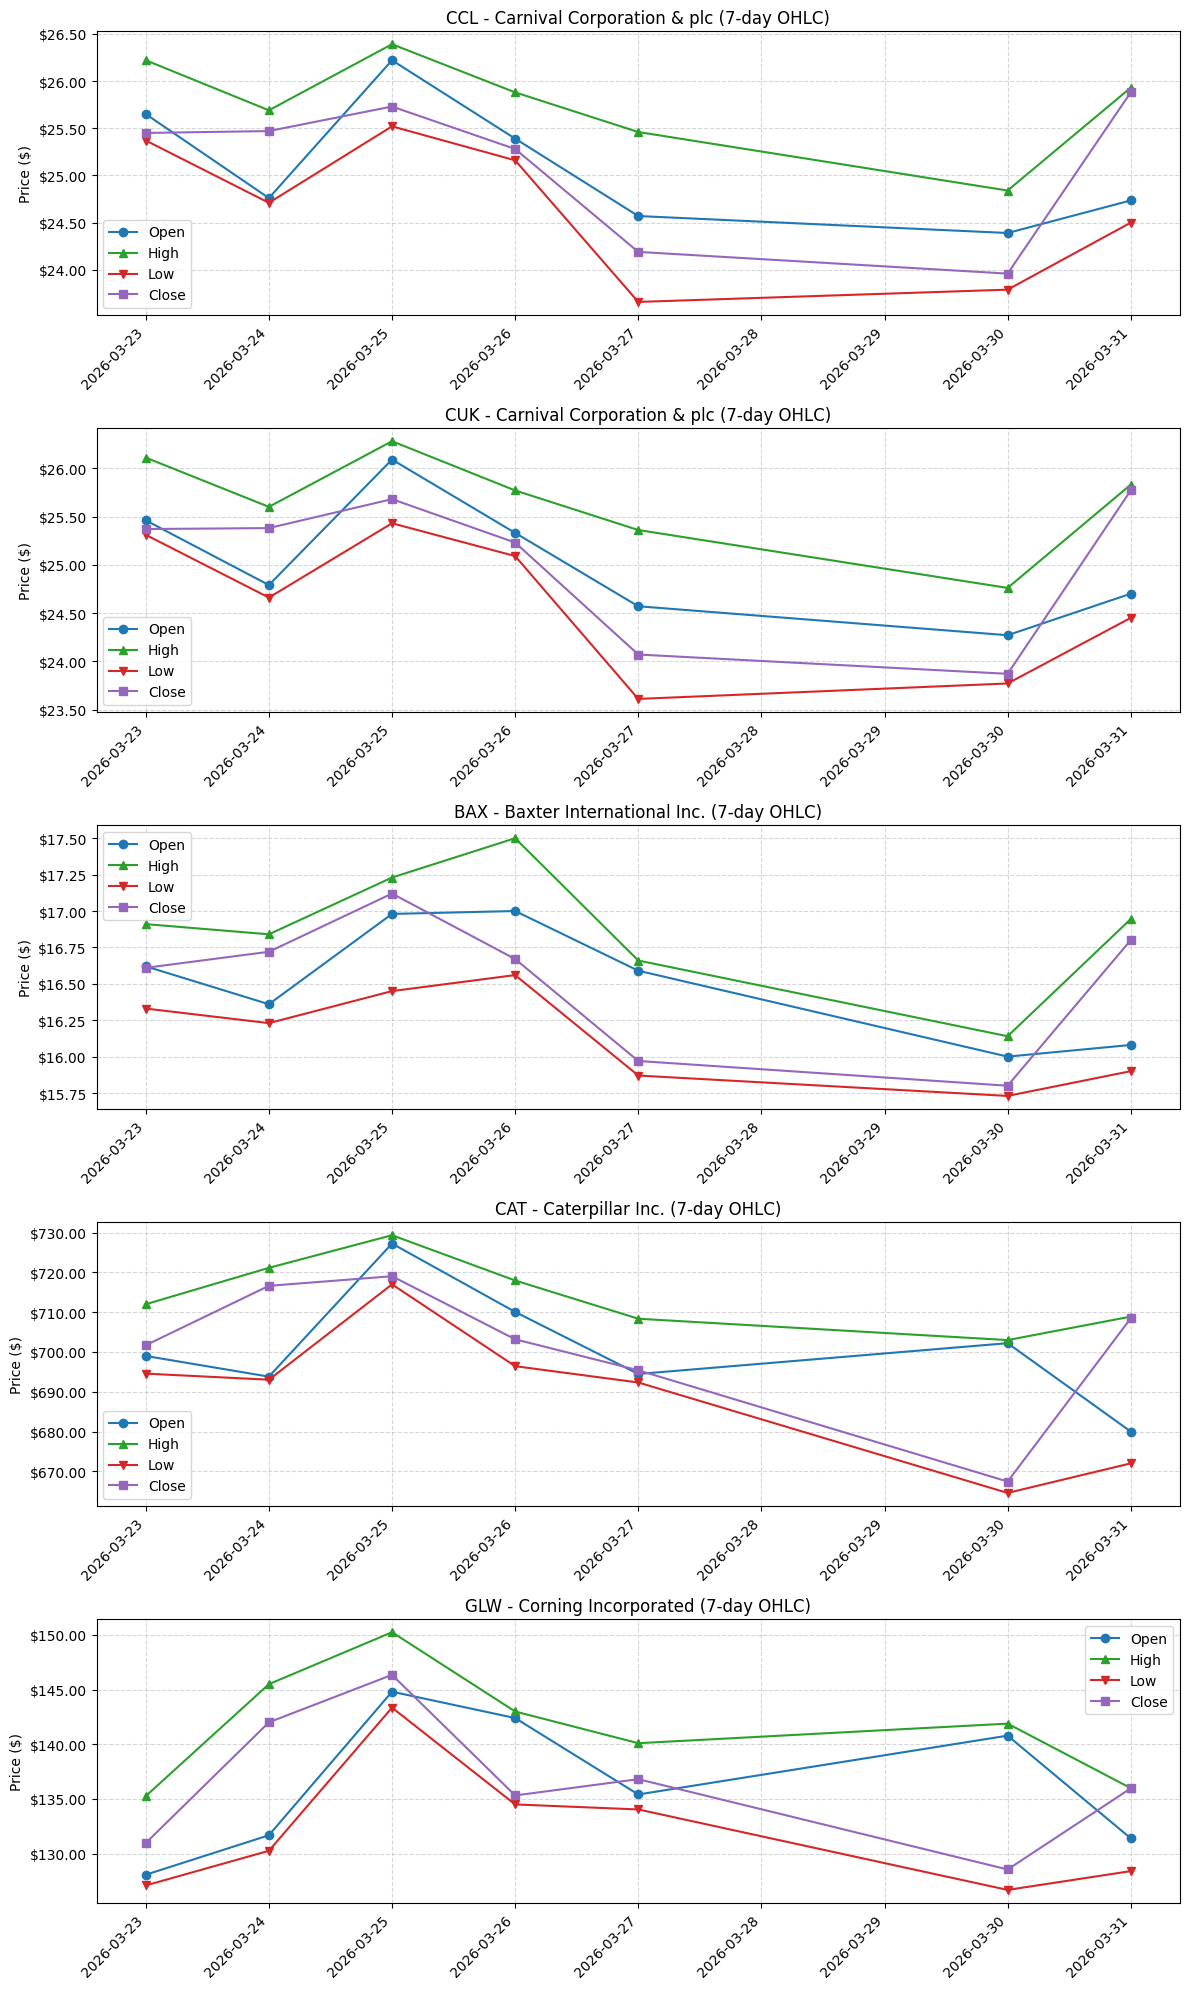

In [21]:
%pip install matplotlib

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def dollar_formatter(x, pos):
    """Format y-axis values as currency."""
    return f"${x:.2f}"

n = len(ohlc_data)
fig, axs = plt.subplots(n, 1, figsize=(12, 4 * max(1, n)), sharex=False)
if n == 1:
    axs = [axs]

for ax, (sym, df) in zip(axs, ohlc_data.items()):
    company_name = get_company_name(sym)
    ax.plot(df.index, df["Open"], marker="o", label="Open", color="tab:blue")
    ax.plot(df.index, df["High"], marker="^", label="High", color="tab:green")
    ax.plot(df.index, df["Low"], marker="v", label="Low", color="tab:red")
    ax.plot(df.index, df["Close"], marker="s", label="Close", color="tab:purple")
    ax.set_title(f"{sym} - {company_name} (7-day OHLC)")
    ax.set_ylabel("Price ($)")
    ax.yaxis.set_major_formatter(FuncFormatter(dollar_formatter))
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

plt.tight_layout()
plt.show()

### This is for "FAVORITED" stocks for tracking - Stocks Watchlist
- AMZN, MSFT, GOOGL, NVDA, META

In [22]:
# Manually inputed data for watchlist and symbol names
WATCHLIST = ["AAPL", "NVDA", "MSFT", "META", "GOOGL"]
SYMBOL_NAMES = {"AAPL": "Apple Inc.", "NVDA": "NVIDIA Corporation", "MSFT": "Microsoft Corporation", "META": "Meta Platforms", "GOOGL": "Alphabet Inc."}

def get_company_name(symbol: str) -> str:
    if symbol in SYMBOL_NAMES: return SYMBOL_NAMES[symbol]
    try:
        info = yf.Ticker(symbol).info
        name = info.get("longName", symbol)
        SYMBOL_NAMES[symbol] = name
        return name
    except: return symbol

def monitor_watchlist(symbols: list[str], delay: float = 0.5):
    performance = []
    for i, sym in enumerate(symbols):
        try:
            hist = yf.Ticker(sym).history(period="2d")
            if len(hist) < 2: continue
            prev_close = hist["Close"].iloc[-2]
            last_close = hist["Close"].iloc[-1]
            pct = (last_close - prev_close) / prev_close * 100
            performance.append((sym, pct))
        except: continue
        time.sleep(delay)
    performance.sort(key=lambda x: x[1], reverse=True)
    return performance

# --- RUN DATA FETCHING ---
results = monitor_watchlist(WATCHLIST)
top_5_results = results[:5]

# This dictionary stores the data
watchlist_ohlc_data = {} 

print("Fetching 7-Day History for Visualization...")
for sym, pct in top_5_results:
    try:
        # Pull 7 days of history
        df = yf.Ticker(sym).history(period="7d")[["Open", "High", "Low", "Close"]]
        watchlist_ohlc_data[sym] = df
        print(f"✓ {sym} loaded.")
    except Exception as e:
        print(f"✗ Could not load {sym}")

Fetching 7-Day History for Visualization...
✓ META loaded.
✓ NVDA loaded.
✓ GOOGL loaded.
✓ MSFT loaded.
✓ AAPL loaded.


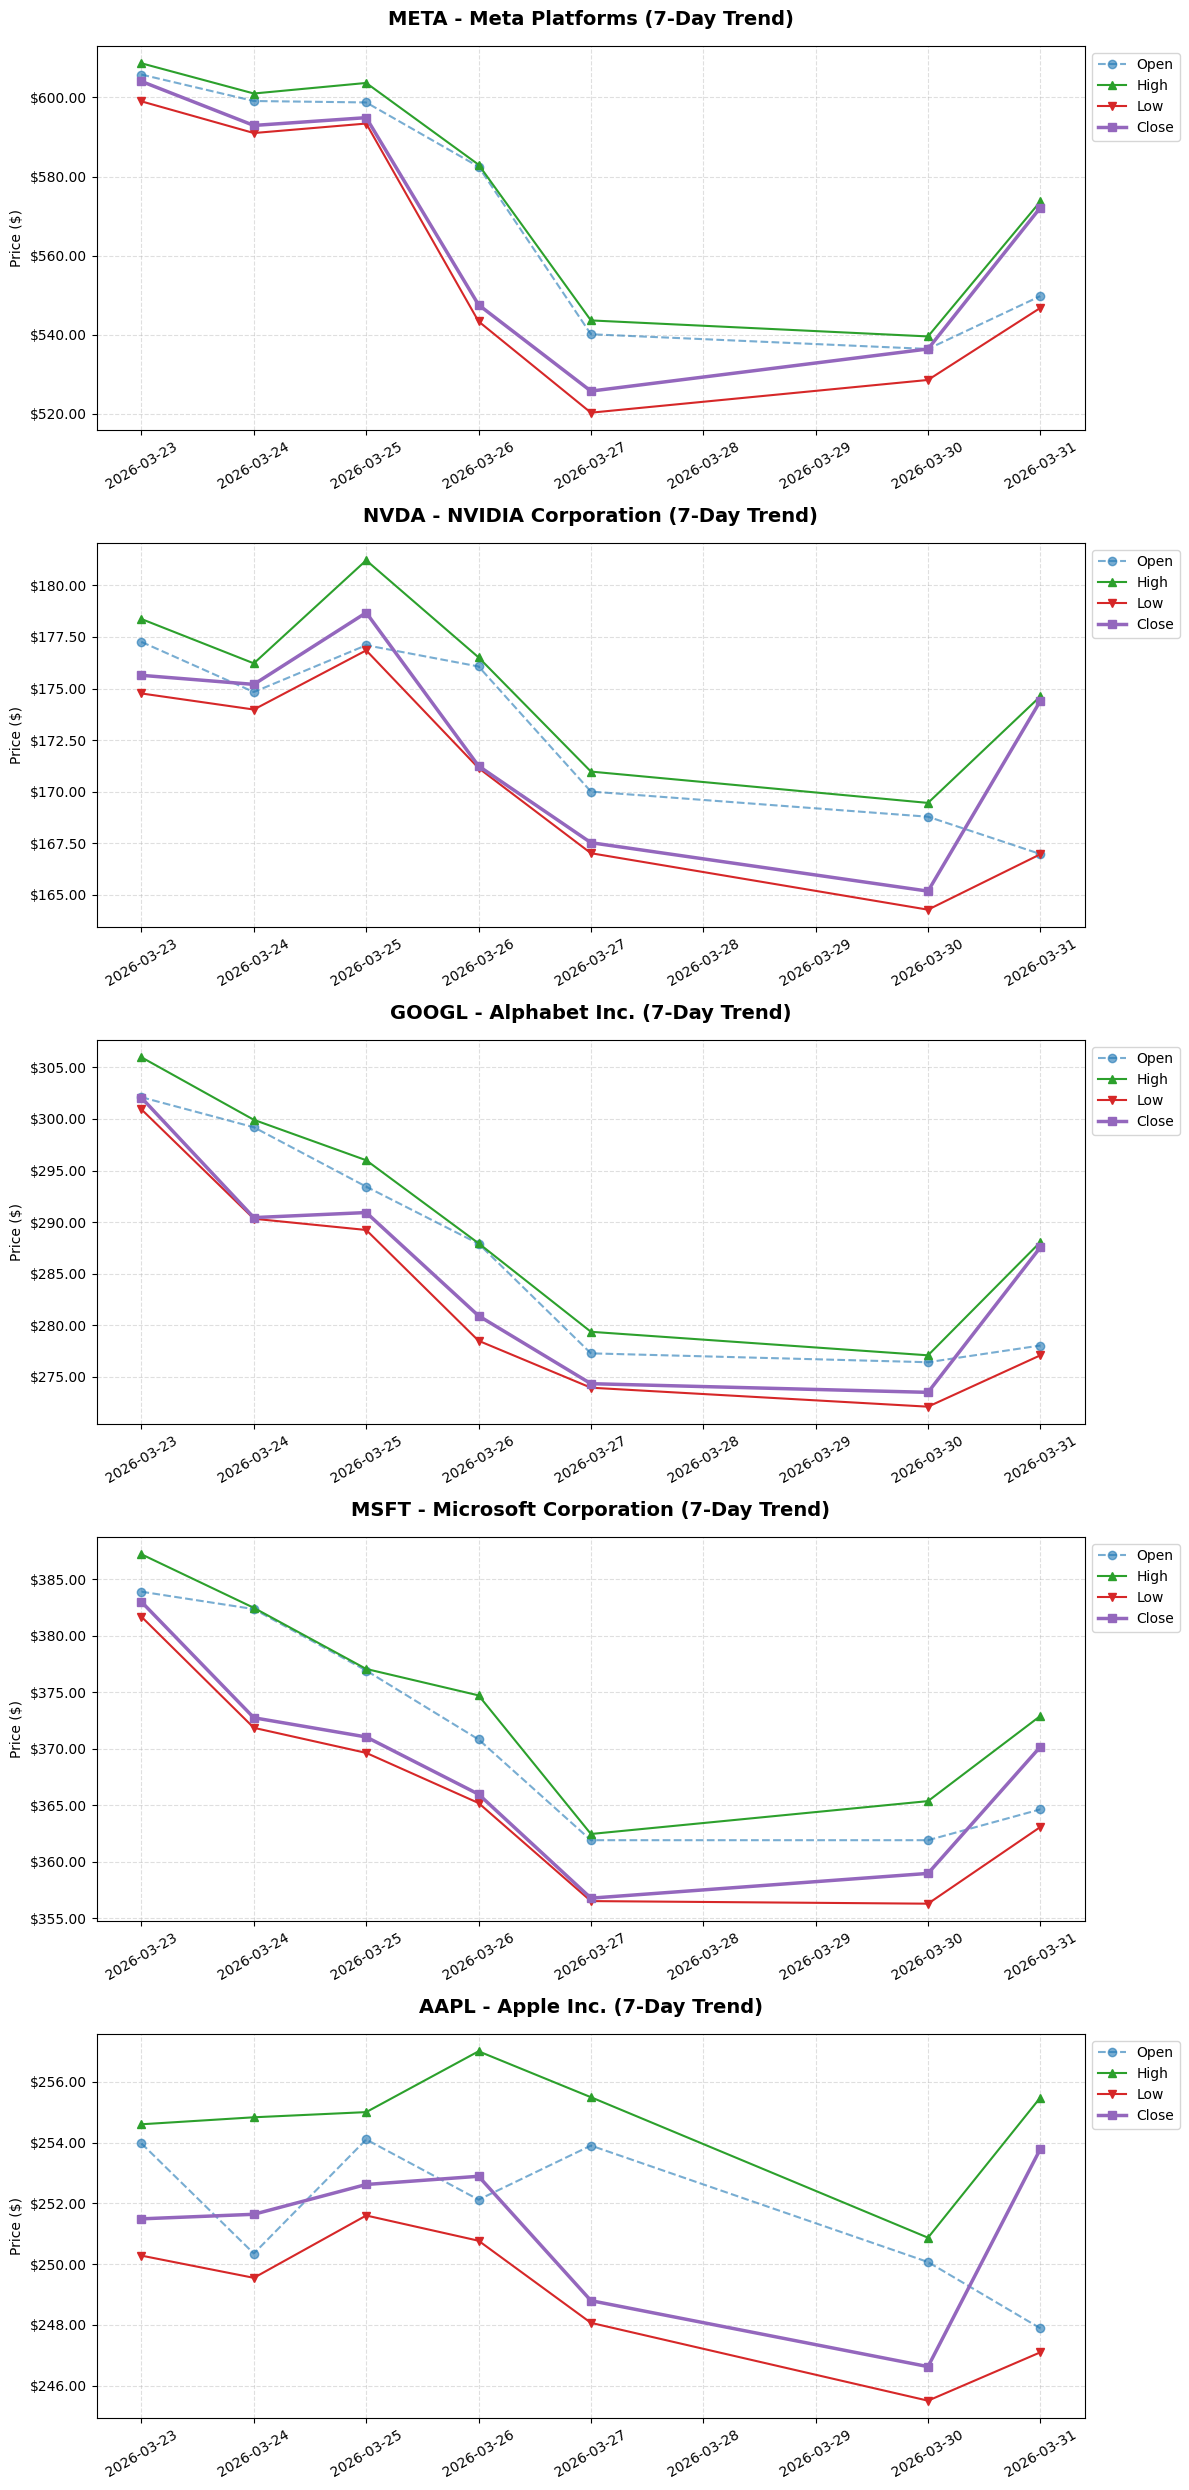

In [23]:
def dollar_formatter(x, pos):
    """Format y-axis values as currency."""
    return f"${x:.2f}"

# 1. Determine how many stocks we are plotting from the dictionary we created
n = len(watchlist_ohlc_data)

if n == 0:
    print("No data available to plot. Please run Cell 1 first.")
else:
    # 2. Create a vertical stack of plots
    fig, axs = plt.subplots(n, 1, figsize=(12, 5 * n), sharex=False)

    # Ensure axs is always an iterable list
    if n == 1:
        axs = [axs]

    # 3. Loop through the stored data
    for ax, (sym, df) in zip(axs, watchlist_ohlc_data.items()):
        company_name = get_company_name(sym)
        
        # Plot the four OHLC components
        ax.plot(df.index, df["Open"], marker="o", label="Open", color="tab:blue", linestyle="--", alpha=0.6)
        ax.plot(df.index, df["High"], marker="^", label="High", color="tab:green", linewidth=1.5)
        ax.plot(df.index, df["Low"], marker="v", label="Low", color="tab:red", linewidth=1.5)
        ax.plot(df.index, df["Close"], marker="s", label="Close", color="tab:purple", linewidth=2.5)

        # Title and Labels
        ax.set_title(f"{sym} - {company_name} (7-Day Trend)", fontsize=14, fontweight='bold', pad=15)
        ax.set_ylabel("Price ($)")
        
        # Formatting
        ax.yaxis.set_major_formatter(FuncFormatter(dollar_formatter))
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(loc="upper left", bbox_to_anchor=(1, 1)) 
        
        # Format the X-axis dates
        ax.tick_params(axis='x', rotation=30)

    # 4. Final Layout Adjustments
    plt.tight_layout()
    plt.show()